In [1]:
import logging
import os
import pdb
import re
import warnings
from pathlib import Path

import cartopy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray
from sklearn.neighbors import BallTree as SKBallTree
from utils import fmt, getfcst, getobs, na_values

warnings.filterwarnings("ignore", category=UserWarning, module="cartopy")

In [43]:
casedir = Path("/glade/campaign/mmm/parc/mwong/ufs-mrw")
workdir = Path("/glade/derecho/scratch/ahijevyc/ks21_tmp")

isensemble = False
# Choose a forecast length (24, 48, 72, or 240 work for deterministic fcsts)
forecast_length = 192 if isensemble else 72

datepos = 0
cases = sorted(casedir.glob(f"[12]?????????.F{forecast_length:03d}.C768"))
if isensemble:
    assert forecast_length in [
        192,
        120,
    ], f"unexpected ensemble forecast_length {forecast_length}"
    cases = sorted(casedir.glob(f"E[12]?????????.p??.F{forecast_length:03d}.C768"))
    datepos = 1


# set extent
lon0 = -131
lon1 = -48
lat0 = 23
lat1 = 65

itimes = [pd.to_datetime(c.name[datepos : datepos + 10], format=fmt) for c in cases]
print(f"found {len(itimes)} init times with {forecast_length}-h forecasts in casedir {casedir}")

# Choose an initialization time index
# 10 in Lupo2023
itimes_index = 10
itimes_index = itimes.index(
    pd.to_datetime("20200409T12") - pd.to_timedelta(min([forecast_length, 96]), "hour")
)

logging.info(f"chose itime={itimes[itimes_index]}")

pd.Series(itimes, name="itime")

found 24 init times with 72-h forecasts in casedir /glade/campaign/mmm/parc/mwong/ufs-mrw


0    2019-10-23 06:00:00
1    2019-11-24 06:00:00
2    2019-12-20 00:00:00
3    2020-02-09 06:00:00
4    2020-02-20 12:00:00
5    2020-03-01 00:00:00
6    2020-04-06 12:00:00
7    2020-04-09 12:00:00
8    2020-05-16 12:00:00
9    2020-08-29 18:00:00
10   2020-09-07 00:00:00
11   2020-10-25 18:00:00
12   2020-11-25 06:00:00
13   2021-03-14 18:00:00
14   2021-04-09 00:00:00
15   2021-04-11 12:00:00
16   2021-04-28 06:00:00
17   2021-10-16 18:00:00
18   2021-10-26 06:00:00
19   2021-12-31 06:00:00
20   2022-02-13 12:00:00
21   2022-04-11 06:00:00
22   2022-05-02 12:00:00
23   2022-06-11 18:00:00
Name: itime, dtype: datetime64[ns]

In [44]:
def xtime(ds: xarray.Dataset):
    """convert xtime variable to datetime and assign to coordinate"""

    # remove one-element-long Time dimension
    ds = ds.squeeze(dim="Time", drop=True)

    logging.info("decode initialization time variable")
    Time = pd.to_datetime(
        ds["Times"].load().item().decode("utf-8").strip(),
        format="%Y-%m-%d_%H:%M:%S",
    )

    # assign initialization time variable to its own coordinate
    ds = ds.assign_coords(
        Time=(
            ["Time"],
            [Time],
        ),
    )
    return ds

In [45]:
parallel = False
if parallel:
    try:
        client.cluster.close()
        client.shutdown()
        client.close()
    except:
        pass

    from dask.distributed import Client

    client = Client(n_workers=8)
    client

In [46]:
for case in cases[itimes_index : itimes_index + 1]:
    ifiles = (case / "interp").glob("interp_fv3_history2d_??????????_f???.nc")
    ifiles = list(ifiles)
    # ignore forecast hours after 96 (only matters for 240-h run)
    ifiles = [ifile for ifile in ifiles if int(ifile.name[-6:-3]) <= 96] 
    ds = xarray.open_mfdataset(
        ifiles, preprocess=xtime, parallel=True, compat="override", coords="minimal"
    )
logging.warning(f"opened {len(ifiles)} files")
logging.info(ifiles)

# Take 1-d lat and 1-d lon coordinates from 2-d XLONG and XLAT
lon = ds.XLONG.isel(south_north=0).values
# lon = np.roll(np.arange(-180, 180, 0.25)+0.25, 360*2+1)
lat = ds.XLAT.isel(west_east=0).values
# lat = np.linspace(90, -90, 180*4+1)
assert all(np.diff(lat) < 0), "expected lat to decrease monotonically"
ds = ds.rename_dims(south_north="lat", west_east="lon").assign_coords(
    lon=("lon", lon), lat=("lat", lat)
)
ds = ds.sel(lat=slice(lat1, lat0), lon=slice(lon0, lon1))

# group same variable from different levels into new variable with vertical dimension
potential_plevs = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50, 10]
for statevar in ["omg", "q", "rh", "t", "u", "v", "z"]:
    for tend in [
        "",
        "cnvgwd",
        "deepcnv",
        "lw",
        "mp",
        "nonphys",
        "ogwd",
        "pbl",
        "rdamp",
        "shalcnv",
        "sw",
    ]:
        potentialvars = [f"d{statevar}3dt{plev}_{tend}" for plev in potential_plevs]
        newvar = f"d{statevar}3dt_{tend}"
        if tend == "":
            potentialvars = [f"{statevar}{plev}" for plev in potential_plevs]
            newvar = statevar
        logging.info(newvar)
        this_vars = [var for var in potentialvars if var in ds]
        if not this_vars:
            continue
        stack = []
        for var in this_vars:
            logging.info(f"{var} {statevar} {tend}")
            plev = int(
                var.removeprefix(f"d{statevar}3dt")
                .removeprefix(statevar)
                .removesuffix(f"_{tend}")
            )
            assert plev, f"unexpected plev {plev}"
            tmpvar = ds[var].expand_dims(pfull=[plev])
            tmpvar.attrs["description"] = tmpvar.attrs["description"].lstrip(f"{plev}-mb ")
            stack.append(tmpvar)
            ds = ds.drop_vars(var)
        ds[newvar] = xarray.concat(stack, dim="pfull")
ds

/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/dask/array/core.py:4832: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/dask/array/core.py:4832: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/dask/array/core.py:4832: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/dask/array/core.py:4832: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/dask/array/core.py:4832: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/glade/u/apps/opt/conda/envs/npl-2024b/lib/python3.11/site-packages/dask/array/core.py:4832: PerformanceW

<xarray.Dataset> Size: 2GB
Dimensions:        (Time: 12, lon: 333, lat: 169, pfull: 14)
Coordinates:
  * Time           (Time) datetime64[ns] 96B 2020-04-06T18:00:00 ... 2020-04-...
  * lon            (lon) float32 1kB -131.0 -130.8 -130.5 ... -48.5 -48.25 -48.0
  * lat            (lat) float32 676B 65.0 64.75 64.5 64.25 ... 23.5 23.25 23.0
  * pfull          (pfull) int64 112B 1000 925 850 700 600 ... 200 150 100 50 10
    XLONG          (lat, lon) float32 225kB dask.array<chunksize=(169, 333), meta=np.ndarray>
    XLAT           (lat, lon) float32 225kB dask.array<chunksize=(169, 333), meta=np.ndarray>
Data variables: (12/188)
    Times          (Time) |S19 228B b'2020-04-06_18:00:00' ... b'2020-04-09_1...
    us             (Time, lat, lon) float32 3MB dask.array<chunksize=(1, 169, 333), meta=np.ndarray>
    vs             (Time, lat, lon) float32 3MB dask.array<chunksize=(1, 169, 333), meta=np.ndarray>
    albdo_ave      (Time, lat, lon) float32 3MB dask.array<chunksize=(1, 169, 333), meta=np.ndarray>
    cprat_ave      (Time, lat, lon) float32 3MB dask.array<chunksize=(1, 169, 333), meta=np.ndarray>
    cpratb_ave     (Time, lat, lon) float32 3MB dask.array<chunksize=(1, 169, 333), meta=np.ndarray>
    ...             ...
    dv3dt_nonphys  (pfull, Time, lat, lon) float32 38MB dask.array<chunksize=(1, 1, 169, 333), meta=np.ndarray>
    dv3dt_ogwd     (pfull, Time, lat, lon) float32 38MB dask.array<chunksize=(1, 1, 169, 333), meta=np.ndarray>
    dv3dt_pbl      (pfull, Time, lat, lon) float32 38MB dask.array<chunksize=(1, 1, 169, 333), meta=np.ndarray>
    dv3dt_rdamp    (pfull, Time, lat, lon) float32 38MB dask.array<chunksize=(1, 1, 169, 333), meta=np.ndarray>
    dv3dt_shalcnv  (pfull, Time, lat, lon) float32 38MB dask.array<chunksize=(1, 1, 169, 333), meta=np.ndarray>
    z              (pfull, Time, lat, lon) float32 38MB dask.array<chunksize=(1, 1, 169, 333), meta=np.ndarray>
Attributes: (12/17)
    WEST-EAST_GRID_DIMENSION:    1441
    SOUTH-NORTH_GRID_DIMENSION:  722
    BOTTOM-TOP_GRID_DIMENSION:   1
    SIMULATION_START_DATE:       2020-04-06_12:00:00
    START_DATE:                  2020-04-06_12:00:00
    VALID_TIME:                  2020-04-06_18:00:00
    ...                          ...
    MOAD_CEN_LAT:                0.0
    STAND_LON:                   0.0
    POLE_LAT:                    90.0
    POLE_LON:                    0.0
    MAP_PROJ:                    6
    MAP_PROJ_CHAR:               Lat/Lon

In [47]:
def tissot(ax: plt.axes, df: pd.DataFrame, **kwargs) -> None:
    """
    Draw circle with Ro(km) radius around (LON(E), LAT(N)).

    Parameters
    ----------
    ax : plt.axes
        axes to draw on
    df : pd.DataFrame
        DataFrame with columns ["Ro(km)", "LON(E)", "LAT(N)"]

    Returns
    -------
    None
    """

    for i, row in df.iterrows():
        t = ax.tissot(
            rad_km=row["Ro(km)"],
            lons=row["LON(E)"],
            lats=row["LAT(N)"],
            **kwargs,
        )
    return

............

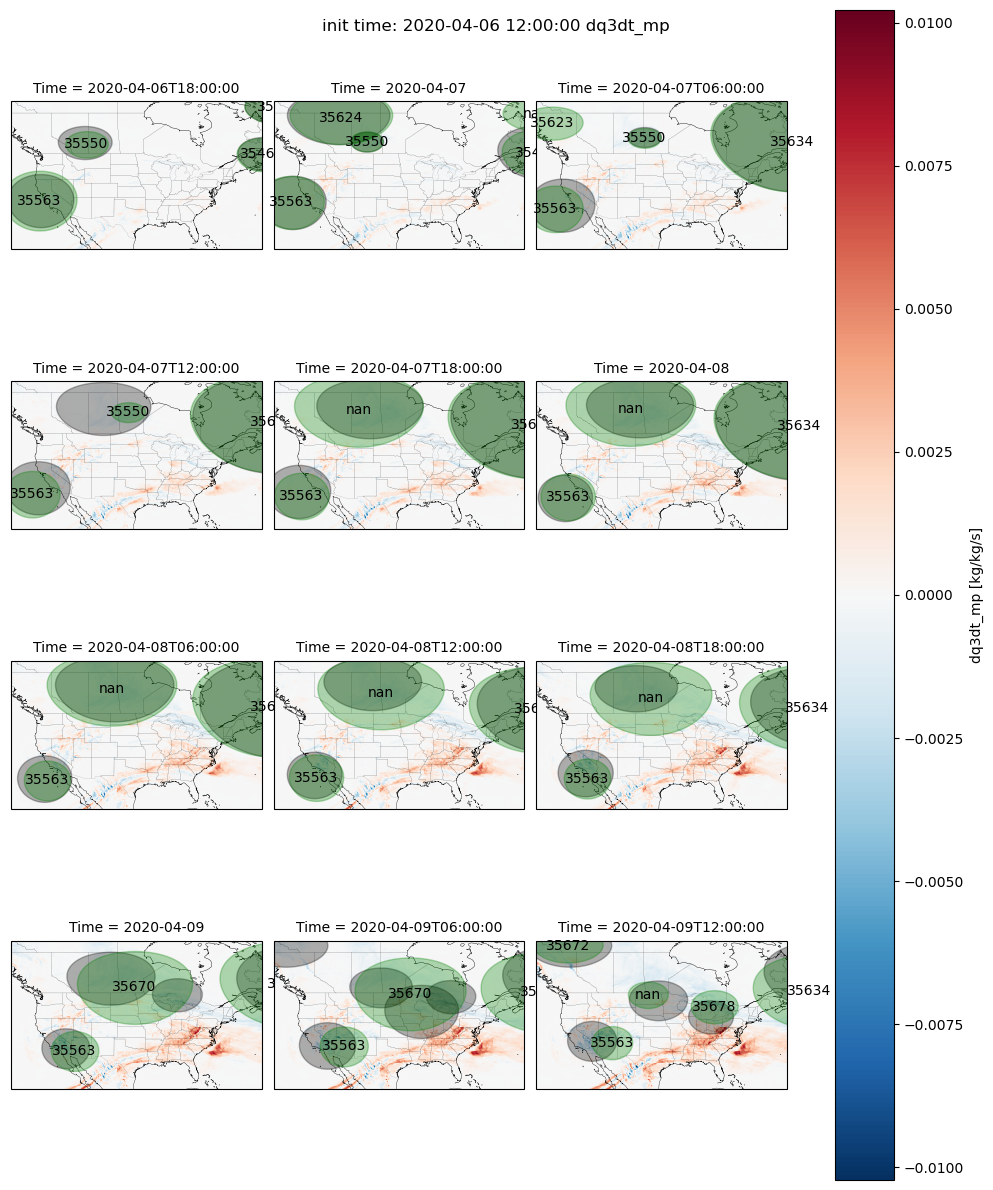

In [48]:
initialization_time = pd.to_datetime(ds.Time)[0] - pd.to_timedelta(6, unit="hour")

# Define stacked 1-d 'pt' coordinate from lat and lon
# so we can use 1-d indices returned from SKBallTree query_radius
ds_pt = ds.stack(pt=("lat", "lon"))

X = np.deg2rad(np.c_[ds_pt.XLAT, ds_pt.XLONG])
tree = SKBallTree(X, metric="haversine")

var = "dq3dt_mp"
plev = 500

projection = cartopy.crs.PlateCarree()
p = (
    ds[var]
    .sel(pfull=plev)
    .plot(
        row="Time",
        col_wrap=3,
        subplot_kws={"projection": projection},
        transform=cartopy.crs.PlateCarree(),
    )
)
def subset_lonlat(df):
    df.loc[df["LON(E)"] >= 180, "LON(E)"] = df.loc[df["LON(E)"] >= 180, "LON(E)"] - 360
    lat = df["LAT(N)"]
    lon = df["LON(E)"]
    df = df[lat.between(lat0, lat1) & lon.between(lon0, lon1)]
    return df
    
for valid_time, ax in zip(ds_pt.Time.values, p.axs.flat):
    coastlines = ax.coastlines(lw=0.25)
    ax.add_feature(cartopy.feature.STATES, lw=0.1, alpha=0.5)
    
    valid_time = pd.to_datetime(valid_time)
    fhr = (valid_time - initialization_time) / pd.Timedelta(hours=1)

    obs = getobs(initialization_time, valid_time)
    fcst = getfcst(initialization_time, valid_time, workdir)

    fcst = subset_lonlat(fcst)
    obs = subset_lonlat(obs)

    for i, row in fcst.iterrows():
        lat = row["LAT(N)"]
        lon = row["LON(E)"]
        r = np.deg2rad(row["Ro(km)"] / 111.0)
        # List pts closest to each latlon element
        (idx,) = tree.query_radius(np.deg2rad([[lat, lon]]), r=r, return_distance=False)
        inblob = ds_pt[var].isel(pt=idx).sel(Time=valid_time).sel(pfull=plev)
        avg = inblob.compute().mean().compute().data
        wgt = np.cos(np.deg2rad(inblob.lat))
        wgtavg = ((inblob * wgt).sum() / wgt.sum()).compute().data
        fcst.loc[i, "avg"] = wgtavg
        logging.info(f"i:{i} {lat}, {lon}: {avg} {wgtavg}")
        ax.text(
            lon,
            lat,
            f"{row.ID:.0f}",
            ha="center",
            va="center",
            transform=cartopy.crs.PlateCarree(),
        )
        # values = ds_pt[var].values
        # values[..., idx] = np.nan # blank out blob data for debugging
        # ds_pt[var] = xarray.DataArray(values, coords=ds_pt[var].coords)

    tissot(ax, obs, alpha=0.3, color="k")
    alpha = 0.3
    tissot(ax, fcst, alpha=alpha, color="green")
    ax.set_extent((lon0, lon1-15, lat0, lat1-6))

ds_pt = ds_pt.unstack()
s = p.fig.suptitle(f"init time: {initialization_time} {var}")

............

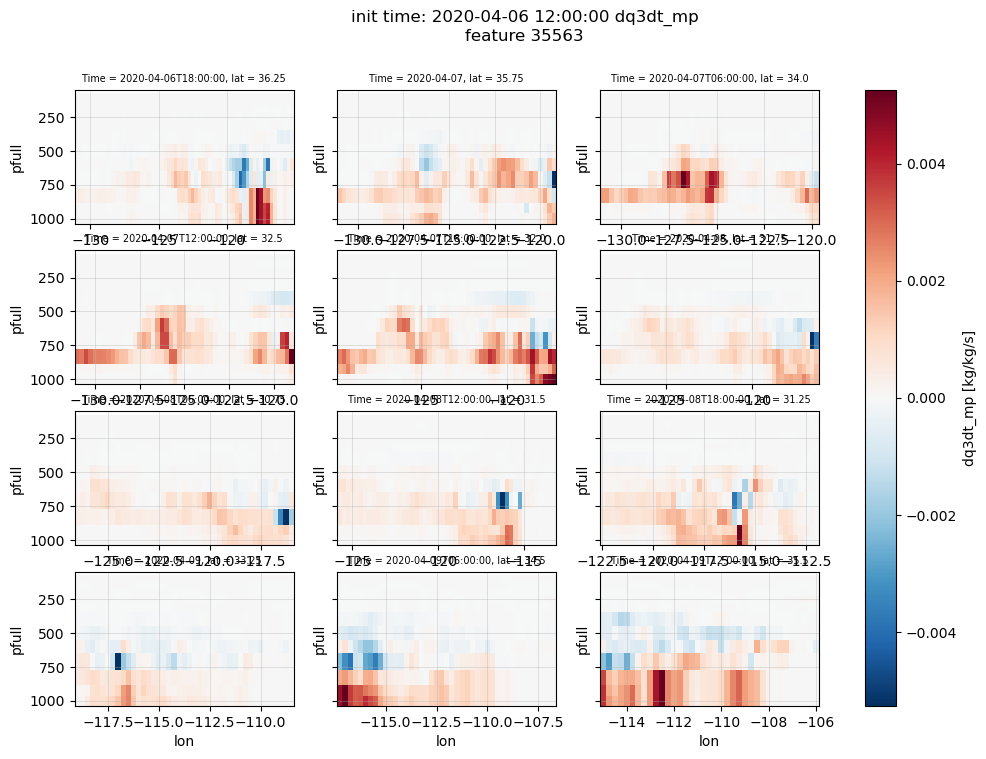

In [50]:
id = 35563
def feature_xs(ds, id, var, ncols=3):
    fig, axes = plt.subplots(
        ncols=ncols, nrows=int(np.ceil(ds.Time.size / ncols)), sharey=True, figsize=(12, 8)
    )
    for valid_time, ax in zip(ds.Time.values, axes.flat):
        valid_time = pd.to_datetime(valid_time)
        fhr = (valid_time - initialization_time) / pd.Timedelta(hours=1)
    
        obs = getobs(initialization_time, valid_time)
        fcst = getfcst(initialization_time, valid_time, workdir)
    
        data = fcst
        f = data[(data.ID == id)]
        if f.empty:
            continue
        (dlon,) = f["Ro(km)"] / 111.0
        (lat,) = f["LAT(N)"].values
        (lon,) = f["LON(E)"].values - 360
        lon = slice(lon - dlon, lon + dlon)
        xs = ds[var].sel(Time=valid_time, lat=lat, lon=lon)
        p = xs.plot(x="lon", y="pfull", ax=ax, add_colorbar=False)
        ax.title.set_size("x-small")
        ax.invert_yaxis()
        ax.set_ylim(top=50)
        ax.grid(alpha=0.5, lw=0.5)
    
    #[ax.set_visible(False) for ax in axes.flat if not ax.has_data()]
    plt.colorbar(p, ax=axes, label=f'{xs.attrs["description"]} [{xs.attrs["units"]}]')
    s = fig.suptitle(f"init time: {initialization_time} {var}\nfeature {id}")
    return fig, axes

fig, axes = feature_xs(ds, id, var)

............

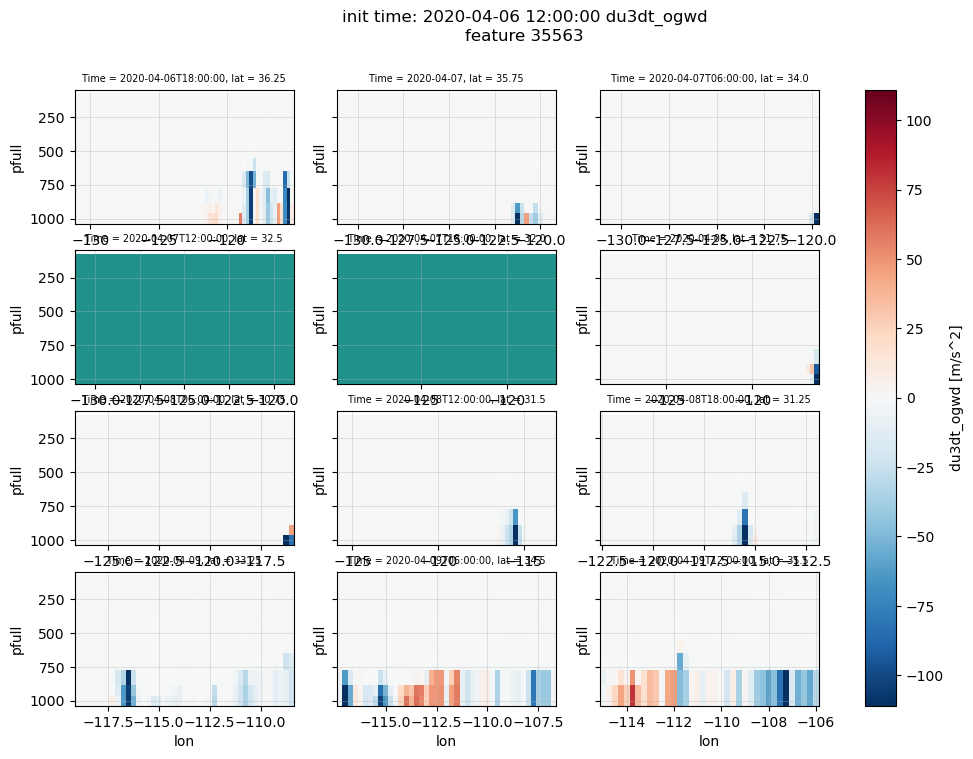

In [51]:
fig, axes = feature_xs(ds, id, "du3dt_ogwd")

............

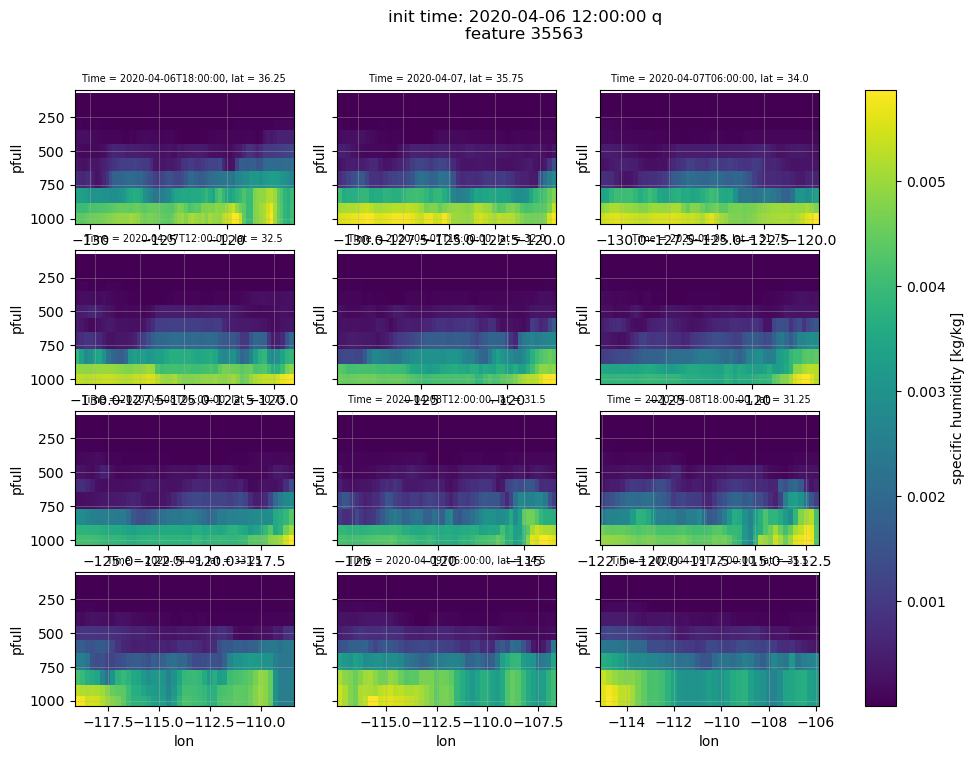

In [52]:
fig, axes = feature_xs(ds, id, "q")